In [11]:
import warnings
warnings.filterwarnings('ignore')

import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


LINKS_CSV   = 'links_export.csv'
SAMPLE_SIZE = 50_000
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'figure.dpi':       130,
})
ACCENT  = '#00d4ff'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a8ff78'


## 2. Load Data & Build Graph

We load `links_export.csv` which contains directed edges (`source_title` → `target_title`).  
The full file has 5.37M rows (~894MB) — we sample `SAMPLE_SIZE` rows for performance.  
Self-loops and null values are dropped as part of cleaning.

In [7]:
print(f'Loading {SAMPLE_SIZE:,} rows from {LINKS_CSV}...')

df = pd.read_csv(
    LINKS_CSV,
    usecols=['source_title', 'target_title'],
    nrows=SAMPLE_SIZE
)

before = len(df)
df = df.dropna(subset=['source_title', 'target_title'])
df = df[df['source_title'] != df['target_title']]  # remove self-loops
after = len(df)
print(f'Rows after cleaning: {after:,} / {before:,} (removed {before - after:,} dirty rows)')

#builkd the graph
G = nx.from_pandas_edgelist(
    df,
    source='source_title',
    target='target_title',
    create_using=nx.DiGraph()
)

print(f'\nGraph built:')
print(f'  Nodes : {G.number_of_nodes():,}')
print(f'  Edges : {G.number_of_edges():,}')
print(f'  Density: {nx.density(G):.6f}')

Loading 50,000 rows from links_export.csv...
Rows after cleaning: 49,996 / 50,000 (removed 4 dirty rows)

Graph built:
  Nodes : 41,795
  Edges : 49,996
  Density: 0.000029


## 3. Centrality Metric

### Metric — PageRank
Simulates a random surfer following links. Score flows from authoritative pages to their neighbors.

In [8]:
print('Computing PageRank...')
pr = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1e-6)
print(f'  Done. PageRank sum = {sum(pr.values()):.6f}  (should be ~1.0)')

print('Computing In-Degree Centrality...')
in_deg_raw  = dict(G.in_degree())
n           = G.number_of_nodes()
in_deg_norm = {k: v / (n - 1) for k, v in in_deg_raw.items()}
print(f'  Done. Max in-degree = {max(in_deg_raw.values())}')

print('Computing Betweenness Centrality (k=500 approximation)...')
btwn = nx.betweenness_centrality(G, k=500, normalized=True, seed=RANDOM_SEED)
print(f'  Done.')


df_centrality = pd.DataFrame({
    'pagerank':       pr,
    'in_degree':      in_deg_norm,
    'in_degree_raw':  in_deg_raw,
    'betweenness':    btwn,
})
df_centrality.index.name = 'article'
df_centrality = df_centrality.sort_values('pagerank', ascending=False)

print(f'\nCentrality DataFrame shape: {df_centrality.shape}')
df_centrality.head(10)

Computing PageRank...
  Done. PageRank sum = 1.000000  (should be ~1.0)
Computing In-Degree Centrality...
  Done. Max in-degree = 100
Computing Betweenness Centrality (k=500 approximation)...
  Done.

Centrality DataFrame shape: (41795, 4)


,pagerank,in_degree,in_degree_raw,betweenness
article,,,,
ISBN (identifier),0.000040,0.002393,100,0.0
Doi (identifier),0.000032,0.001603,67,0.0
Azerbaijan,0.000031,0.000359,15,0.0
Baku,0.000031,0.000215,9,0.0
Wayback Machine,0.000029,0.001196,50,0.0
Earthquake,0.000029,0.000072,3,0.0
Chronology,0.000029,0.000048,2,0.0
Michael the Syrian,0.000029,0.000024,1,0.0
Armenian highlands,0.000029,0.000024,1,0.0


# top 15 Articles by PageRank  figure

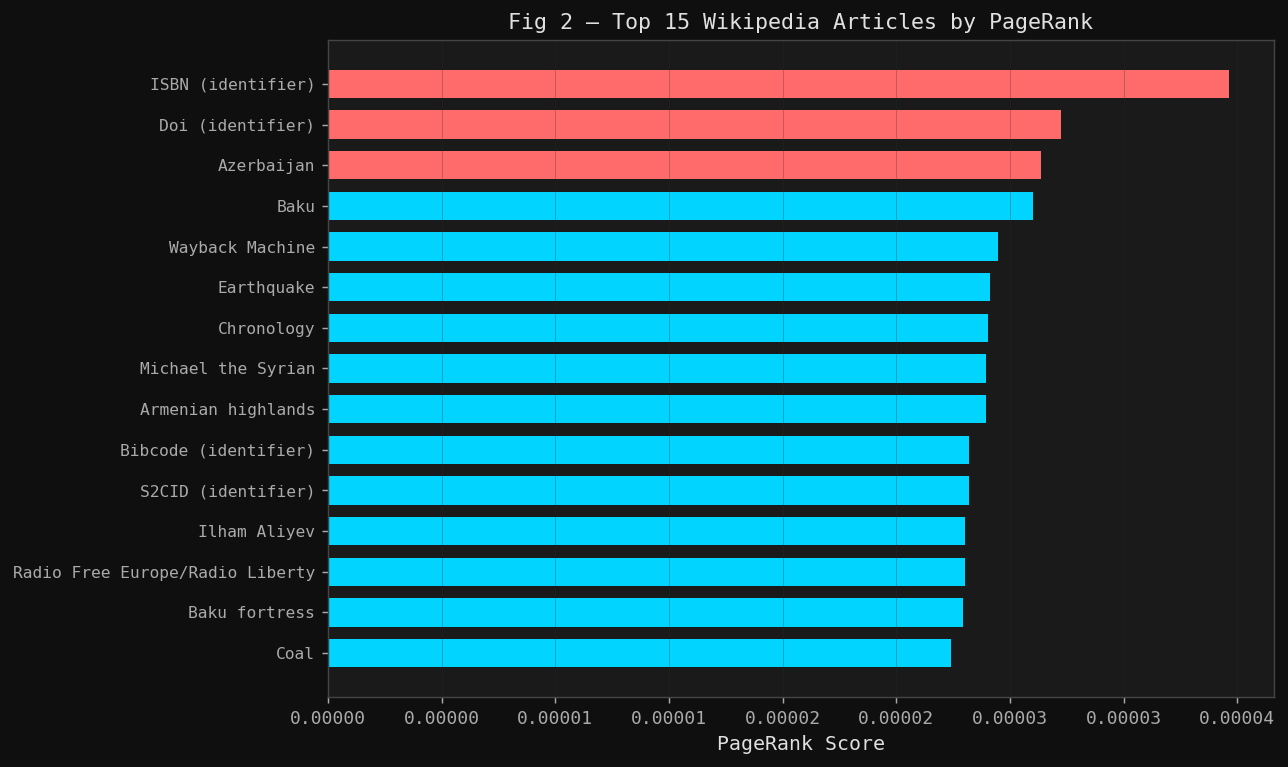

In [9]:
top_pr = df_centrality.nlargest(15, 'pagerank')[['pagerank']].iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT2 if i >= len(top_pr) - 3 else ACCENT for i in range(len(top_pr))]
ax.barh(range(len(top_pr)), top_pr['pagerank'].values,
        color=colors, edgecolor='none', height=0.7)

ax.set_yticks(range(len(top_pr)))
ax.set_yticklabels(
    [t[:55] + '…' if len(t) > 55 else t for t in top_pr.index], fontsize=9
)
ax.set_xlabel('PageRank Score', fontsize=11)
ax.set_title('Fig 2 — Top 15 Wikipedia Articles by PageRank', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_top_pagerank.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()